In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display config
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

# Paths
DATA_RAW = Path('../data/raw')
PRODUCTS_CSV = DATA_RAW / 'amazon_products.csv'
CATEGORIES_CSV = DATA_RAW / 'amazon_categories.csv'

# Target categories (locked after initial category exploration)
TARGET_CATEGORIES = {
    71:  'Headphones & Earbuds',
    79:  'Camera & Photo',
    75:  'Cell Phones & Accessories',
    113: 'Watches (Men\'s)',     # Will be merged with 121 into one 'Watches' bucket
    121: 'Watches (Women\'s)',
    65:  'Laptop Accessories',
}

# Bucket mapping: raw category_id -> our 5-category label used downstream
BUCKET_MAP = {
    71:  'Headphones',
    79:  'Cameras',
    75:  'Phones',
    113: 'Watches',
    121: 'Watches',
    65:  'LaptopAccessories',
}

print(f'Products CSV exists: {PRODUCTS_CSV.exists()}')
print(f'Categories CSV exists: {CATEGORIES_CSV.exists()}')

Products CSV exists: True
Categories CSV exists: True


## 1. Load & Inspect Raw Data

In [4]:
# L
df = pd.read_csv(PRODUCTS_CSV)
cats = pd.read_csv(CATEGORIES_CSV)

print(f'Products: {len(df):,} rows, {df.shape[1]} columns')
print(f'Categories: {len(cats):,} rows')
print()
print('Memory usage:', df.memory_usage(deep=True).sum() / 1024**2, 'MB')

Products: 1,426,337 rows, 11 columns
Categories: 248 rows

Memory usage: 422.7046728134155 MB


In [5]:
# Column dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1426337 entries, 0 to 1426336
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   asin               1426337 non-null  str    
 1   title              1426336 non-null  str    
 2   imgUrl             1426337 non-null  str    
 3   productURL         1426337 non-null  str    
 4   stars              1426337 non-null  float64
 5   reviews            1426337 non-null  int64  
 6   price              1426337 non-null  float64
 7   listPrice          1426337 non-null  float64
 8   category_id        1426337 non-null  int64  
 9   isBestSeller       1426337 non-null  bool   
 10  boughtInLastMonth  1426337 non-null  int64  
dtypes: bool(1), float64(3), int64(3), str(4)
memory usage: 422.7 MB


In [6]:
# Sample rows
df.head(5)

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black, Checked-Large 29-Inch",https://m.media-amazon.com/images/I/815dLQKYIYL._AC_UL320_.jpg,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcase Double Wheels TSA Lock Blue,https://m.media-amazon.com/images/I/81bQlm7vf6L._AC_UL320_.jpg,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,"Platinum Elite Softside Expandable Checked Luggage, 8 Wheel Spinner Suitcase...",https://m.media-amazon.com/images/I/71EA35zvJBL._AC_UL320_.jpg,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,"Freeform Hardside Expandable with Double Spinner Wheels, Navy, 2-Piece Set (...",https://m.media-amazon.com/images/I/91k6NYLQyIL._AC_UL320_.jpg,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,"Winfield 2 Hardside Expandable Luggage with Spinner Wheels, Checked-Large 28...",https://m.media-amazon.com/images/I/61NJoaZcP9L._AC_UL320_.jpg,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [7]:
# Numeric column summary
df[['stars', 'reviews', 'price', 'listPrice', 'boughtInLastMonth']].describe()

,stars,reviews,price,listPrice,boughtInLastMonth
count,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06
mean,3.999512e+00,1.807508e+02,4.337540e+01,1.244916e+01,1.419823e+02
std,1.344292e+00,1.761453e+03,1.302893e+02,4.611198e+01,8.362720e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.100000e+00,0.000000e+00,1.199000e+01,0.000000e+00,0.000000e+00
50%,4.400000e+00,0.000000e+00,1.995000e+01,0.000000e+00,0.000000e+00
75%,4.600000e+00,0.000000e+00,3.599000e+01,0.000000e+00,5.000000e+01
max,5.000000e+00,3.465630e+05,1.973181e+04,9.999900e+02,1.000000e+05


## 2. Category Filtering

In [8]:
# Filter to target categories only
df_targets = df[df['category_id'].isin(TARGET_CATEGORIES.keys())].copy()
df_targets['bucket'] = df_targets['category_id'].map(BUCKET_MAP)

print(f'After category filter: {len(df_targets):,} rows '
      f'({len(df_targets)/len(df)*100:.2f}% of original)')
print()
print('Counts per raw category:')
for cid, name in TARGET_CATEGORIES.items():
    n = (df_targets['category_id'] == cid).sum()
    print(f'  {cid:>4} {name:<32} {n:>7,}')
print()
print('Counts per final bucket (5 categories):')
print(df_targets['bucket'].value_counts().to_string())

After category filter: 44,999 rows (3.15% of original)

Counts per raw category:
    71 Headphones & Earbuds               9,242
    79 Camera & Photo                     6,169
    75 Cell Phones & Accessories          3,444
   113 Watches (Men's)                   12,839
   121 Watches (Women's)                  6,542
    65 Laptop Accessories                 6,763

Counts per final bucket (5 categories):
bucket
Watches              19381
Headphones            9242
LaptopAccessories     6763
Cameras               6169
Phones                3444


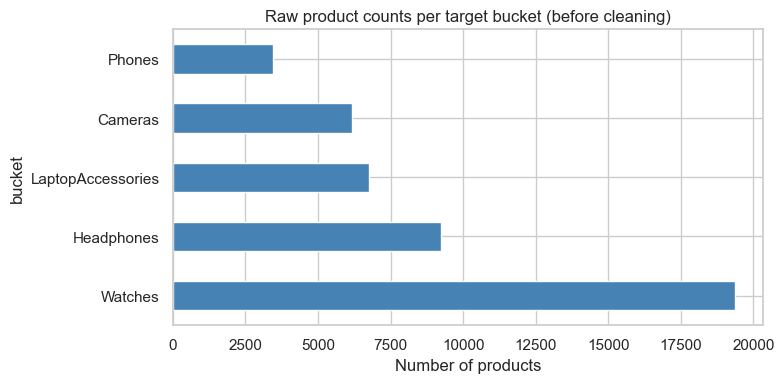

In [9]:
# bucket distribution
fig, ax = plt.subplots(figsize=(8, 4))
df_targets['bucket'].value_counts().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of products')
ax.set_title('Raw product counts per target bucket (before cleaning)')
plt.tight_layout()
plt.show()

## 3. Missing Values

In [10]:
# Missing value counts per column, overall and per bucket
essential_cols = ['title', 'price', 'stars', 'reviews', 'category_id']

print('Overall missing values within target categories:')
missing = df_targets[essential_cols].isna().sum()
missing_pct = (df_targets[essential_cols].isna().mean() * 100).round(2)
summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(summary)
print()


print('Zero-value counts (often a proxy for missing):')
for col in ['price', 'stars', 'reviews']:
    zero_count = (df_targets[col] == 0).sum()
    zero_pct = (df_targets[col] == 0).mean() * 100
    print(f'  {col:<10} zeros: {zero_count:>7,} ({zero_pct:.2f}%)')

Overall missing values within target categories:
             missing_count  missing_pct
title                    0          0.0
price                    0          0.0
stars                    0          0.0
reviews                  0          0.0
category_id              0          0.0

Zero-value counts (often a proxy for missing):
  price      zeros:   1,085 (2.41%)
  stars      zeros:   3,296 (7.32%)
  reviews    zeros:  31,510 (70.02%)


In [11]:
# Per-bucket missing/zero analysis
print('Missing or zero values per bucket:')
print()
rows = []
for bucket in df_targets['bucket'].unique():
    sub = df_targets[df_targets['bucket'] == bucket]
    rows.append({
        'bucket': bucket,
        'total': len(sub),
        'price_zero': (sub['price'] == 0).sum(),
        'stars_zero': (sub['stars'] == 0).sum(),
        'reviews_zero': (sub['reviews'] == 0).sum(),
        'title_na': sub['title'].isna().sum(),
    })
bucket_missing = pd.DataFrame(rows).set_index('bucket')
bucket_missing['after_clean_estimate'] = bucket_missing.apply(
    lambda r: r['total'] - max(r['price_zero'], r['stars_zero'], r['reviews_zero']),
    axis=1
)
print(bucket_missing.to_string())

Missing or zero values per bucket:

                   total  price_zero  stars_zero  reviews_zero  title_na  after_clean_estimate
bucket                                                                                        
Headphones          9242         280         780          1434         0                  7808
Cameras             6169         153         119          6169         0                     0
Watches            19381         618        2158         13700         0                  5681
LaptopAccessories   6763          22         189          6763         0                     0
Phones              3444          12          50          3444         0                     0


## 4. Duplicates

In [12]:
# ASIN duplicates within targets
asin_dups = df_targets.duplicated(subset='asin').sum()
title_dups = df_targets.duplicated(subset='title').sum()

print(f'Duplicate ASINs (within target categories): {asin_dups:,}')
print(f'Duplicate titles (within target categories): {title_dups:,}')
print()
print(f'Unique ASINs: {df_targets["asin"].nunique():,} / {len(df_targets):,} total')
print(f'Unique titles: {df_targets["title"].nunique():,} / {len(df_targets):,} total')

Duplicate ASINs (within target categories): 0
Duplicate titles (within target categories): 1,285

Unique ASINs: 44,999 / 44,999 total
Unique titles: 43,714 / 44,999 total


In [13]:
if title_dups > 0:
    dup_titles = df_targets[df_targets.duplicated(subset='title', keep=False)]
    sample_title = dup_titles['title'].value_counts().index[0]
    print(f'Example of a duplicated title (appears {(dup_titles["title"] == sample_title).sum()} times):')
    print(f'  "{sample_title}"')
    print()
    print('Sample rows for that title:')
    print(dup_titles[dup_titles['title'] == sample_title].head(3)[['asin', 'title', 'price', 'stars', 'reviews']].to_string())
else:
    print('No duplicate titles found.')

Example of a duplicated title (appears 41 times):
  "Women's Bracelet Watch"

Sample rows for that title:
               asin                   title  price  stars  reviews
1099379  B0006MFKJS  Women's Bracelet Watch   0.00    4.4     3044
1099385  B000U5O5XI  Women's Bracelet Watch  27.43    4.5     2564
1099391  B00ZHNQQ26  Women's Bracelet Watch  23.80    4.5    13382


## 5. Price Distribution

In [14]:
# Filter to non-zero prices for distribution analysis
df_pricing = df_targets[df_targets['price'] > 0].copy()

print('Price summary per bucket (non-zero prices only):')
print(df_pricing.groupby('bucket')['price'].describe().round(2).to_string())

Price summary per bucket (non-zero prices only):
                     count    mean     std   min    25%    50%     75%      max
bucket                                                                         
Cameras             6016.0  164.66  414.25  0.10  18.88  39.99  119.99  6799.00
Headphones          8962.0   54.37  125.25  2.25  15.99  25.99   49.99  4999.00
LaptopAccessories   6741.0   38.49   55.05  0.99  12.99  24.92   39.99  1299.99
Phones              3432.0   25.19   50.95  2.99   9.60  13.99   21.99  1099.00
Watches            18763.0  112.77  185.38  0.01  24.99  54.99  127.08  5750.00


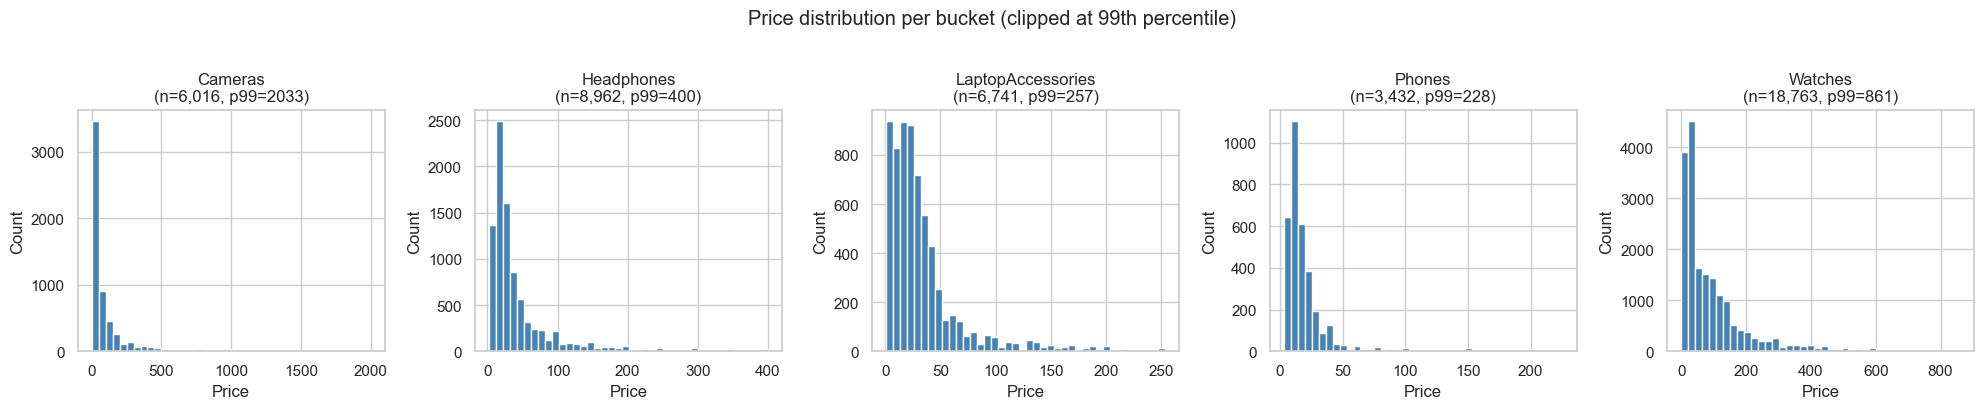

In [15]:
# Price distribution per bucket
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
buckets = sorted(df_pricing['bucket'].unique())
for ax, bucket in zip(axes, buckets):
    sub = df_pricing[df_pricing['bucket'] == bucket]
    # Clip top 1% to prevent extreme outliers dominating the plot
    p99 = sub['price'].quantile(0.99)
    sub_clipped = sub[sub['price'] <= p99]
    ax.hist(sub_clipped['price'], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'{bucket}\n(n={len(sub):,}, p99={p99:.0f})')
    ax.set_xlabel('Price')
    ax.set_ylabel('Count')
plt.suptitle('Price distribution per bucket (clipped at 99th percentile)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Rating & Review Distribution

In [16]:
# Stars distribution (non-zero only)
df_rated = df_targets[df_targets['stars'] > 0].copy()

print('Stars summary per bucket (rated products only):')
print(df_rated.groupby('bucket')['stars'].describe().round(2).to_string())
print()
print('Fraction of products with stars >= 4.0 per bucket:')
for bucket in sorted(df_rated['bucket'].unique()):
    sub = df_rated[df_rated['bucket'] == bucket]
    frac = (sub['stars'] >= 4.0).mean()
    print(f'  {bucket:<20} {frac:.1%}')

Stars summary per bucket (rated products only):
                     count  mean   std  min  25%  50%  75%  max
bucket                                                         
Cameras             6050.0  4.47  0.34  1.0  4.3  4.5  4.7  5.0
Headphones          8462.0  4.05  0.61  1.0  3.8  4.2  4.4  5.0
LaptopAccessories   6574.0  4.44  0.34  1.0  4.3  4.5  4.6  5.0
Phones              3394.0  4.36  0.37  1.0  4.3  4.4  4.6  5.0
Watches            17223.0  4.28  0.57  1.0  4.1  4.4  4.6  5.0

Fraction of products with stars >= 4.0 per bucket:
  Cameras              94.3%
  Headphones           67.0%
  LaptopAccessories    93.5%
  Phones               91.1%
  Watches              81.6%


In [17]:
# Reviews distribution
df_reviewed = df_targets[df_targets['reviews'] > 0].copy()

print('Reviews summary per bucket (reviewed products only):')
print(df_reviewed.groupby('bucket')['reviews'].describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_string())
print()
print('Fraction of products with reviews >= 1000 per bucket:')
for bucket in sorted(df_reviewed['bucket'].unique()):
    sub = df_reviewed[df_reviewed['bucket'] == bucket]
    frac = (sub['reviews'] >= 1000).mean()
    print(f'  {bucket:<20} {frac:.1%}')

Reviews summary per bucket (reviewed products only):
             count    mean     std  min   25%   50%    75%     90%      99%       max
bucket                                                                               
Headphones  7808.0  1224.9  5404.7  1.0  18.0  91.5  538.0  2379.5  19285.4  174524.0
Watches     5681.0   302.0  1320.0  1.0   5.0  25.0  138.0   604.0   5041.2   47467.0

Fraction of products with reviews >= 1000 per bucket:
  Headphones           17.9%
  Watches              6.4%


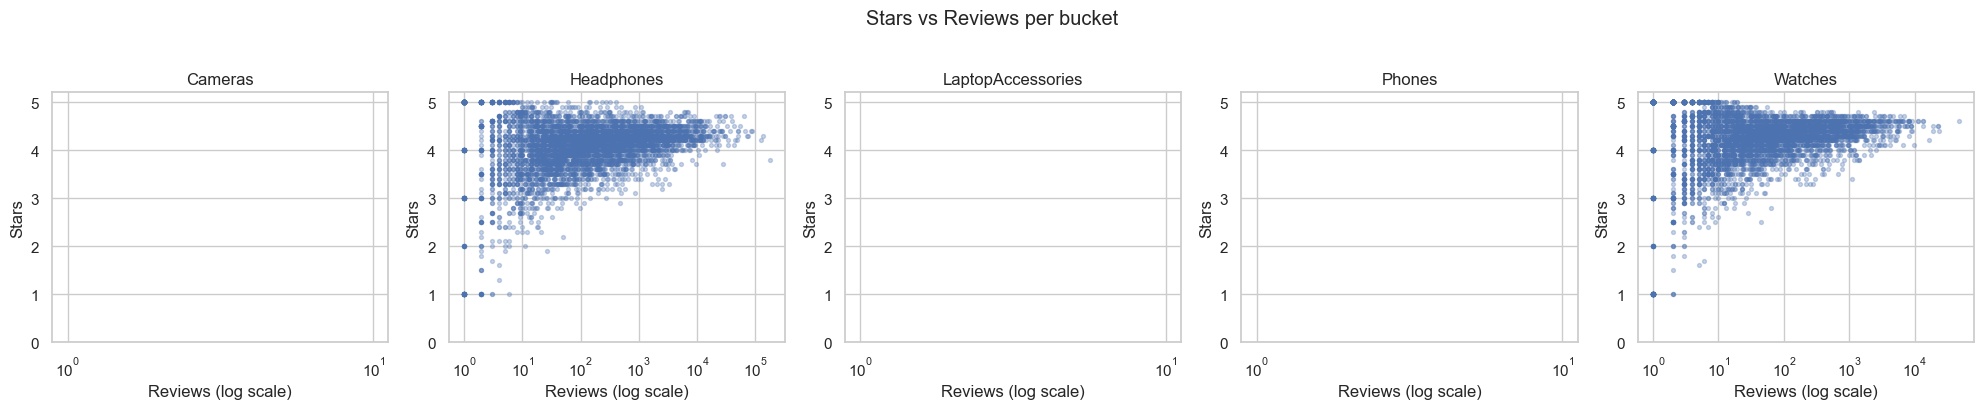

In [18]:
# Combined stars vs reviews scatter per bucket
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, bucket in zip(axes, sorted(df_targets['bucket'].unique())):
    sub = df_targets[(df_targets['bucket'] == bucket) & 
                     (df_targets['stars'] > 0) & 
                     (df_targets['reviews'] > 0)]
    # Sample down for visualisation if too many points
    if len(sub) > 5000:
        sub = sub.sample(5000, random_state=42)
    ax.scatter(sub['reviews'], sub['stars'], alpha=0.3, s=8)
    ax.set_xscale('log')
    ax.set_title(bucket)
    ax.set_xlabel('Reviews (log scale)')
    ax.set_ylabel('Stars')
    ax.set_ylim(0, 5.2)
plt.suptitle('Stars vs Reviews per bucket', y=1.02)
plt.tight_layout()
plt.show()

## 7. Cell Phones Deep-Dive

In [19]:
phones = df_targets[df_targets['bucket'] == 'Phones'].copy()
print(f'Total products in Phones bucket: {len(phones):,}')
print()
print('Sample of titles:')
for title in phones['title'].sample(15, random_state=42).values:
    print(f'  - {title[:120]}')

Total products in Phones bucket: 3,444

Sample of titles:
  - Syncwire Privacy Screen Protector for iPhone 12/12 Pro 6.1" [2-Pack], Anti Spy Tempered Glass Film with Auto Alignment T
  - 6 Pack Sport Bands Compatible with Apple Watch Band 38mm 40mm 41mm 42mm 44mm 45mm 49mm,Soft Silicone Waterproof Strap Co
  - Side Winder Mini and Max Headphone, Earbud and Charging Cable Winder and Organizer Perfect for Wrapping Earbuds and Cord
  - Privacy Screen Protector compatible with iPhone 11 /iPhone XR, 6.1 inch Gradient Colorful Electroplated Anti-Spy Anti-Bl
  - 3 Pack Screen Protector Case, GHIJKL Ultra-Thin Slim Soft TPU Protective All-Around Full Cover Bumper Shell Compatible F
  - USB C Female to USB Male Adapter (3-Pack),Type C to USB A Charger Cable Adapter,Compatible with iPhone 15 14 Pro 13 12 1
  - Galaxy Watch 4 Bands 2 Pack,Compatible with Samsung Galaxy Watch 4 Classic 46mm 42mm Bands, for Galaxy Watch 4 40mm 44mm
  - Replacement Silicone Ear Tips Earbuds Buds Set for Powerbeats 2

In [20]:
# Heuristic accessory detection
accessory_keywords = ['case', 'cover', 'charger', 'screen protector', 'cable', 
                      'adapter', 'holder', 'mount', 'stand', 'sticker', 'skin',
                      'lanyard', 'strap', 'wallet', 'sleeve', 'pouch']

# Build regex pattern for case-insensitive match
pattern = '|'.join(accessory_keywords)
phones['is_accessory'] = phones['title'].str.lower().str.contains(pattern, na=False)

accessory_pct = phones['is_accessory'].mean() * 100
print(f'Estimated accessories in Phones bucket: {phones["is_accessory"].sum():,} '
      f'({accessory_pct:.1f}%)')
print()
print('Likely actual phones (sample):')
actual_phones = phones[~phones['is_accessory']]
for title in actual_phones['title'].sample(min(10, len(actual_phones)), random_state=42).values:
    print(f'  - {title[:120]}')
print()
print(f'Likely actual phones in bucket: {len(actual_phones):,}')

Estimated accessories in Phones bucket: 2,824 (82.0%)

Likely actual phones (sample):
  - Tile Pro 2-Pack (Black/White). Powerful Bluetooth Tracker, Keys Finder and Item Locator for Keys, Bags, and More; Up to 
  - RGB Selfie Light, 360° Full Color LED Phone Light,2000mAH Photography Lighting with Clip and Cold Shoe for Phone/Laptop/
  - Bluetooth Headset, Wireless Bluetooth Earpiece V5.0 Hands-Free Earphones with Built-in Mic for Driving/Business/Office, 
  - Smartphone Video Kit, Vlogging Kit, Youtuber Kit, with Microphone Light Tripod 50" Extendable Phone Clip Remote Control 
  - for iPhone 11 Screen Replacement Black, 3D Touch Digitizer Full HD LCD Display Replacement Retina Assembly with Repair T
  - ArcWave Portable Bluetooth Speaker, High Powered Loud Speaker, Bass Boost, IPX5 Waterproof, Dual Speaker Pairing, Wirele
  - for iPhone 8 Plus Screen Replacement Black 5.5 Inch, Diykitpl 3D Touch LCD Digitizer Display for iPhone 8 Plus, with Rep
  - Professional Replacement Ear Pads f

In [21]:
# Price ranges for accessories vs likely phones (sanity check)
print('Price distribution — accessories vs likely phones:')
print(phones[phones['price'] > 0].groupby('is_accessory')['price'].describe().round(2).to_string())

Price distribution — accessories vs likely phones:
               count   mean    std   min    25%    50%    75%     max
is_accessory                                                         
False          619.0  52.95  84.82  3.19  13.99  21.97  45.99   650.0
True          2813.0  19.08  37.14  2.99   8.99  12.99  19.98  1099.0


## 8. Brand Extraction Preview

In [22]:
# Extract first 1-2 words as a brand candidate
df_targets['brand_candidate'] = df_targets['title'].fillna('').str.split().str[0]

print('Top 20 brand candidates per bucket:')
for bucket in sorted(df_targets['bucket'].unique()):
    print(f'\n--- {bucket} ---')
    top_brands = df_targets[df_targets['bucket'] == bucket]['brand_candidate'].value_counts().head(20)
    print(top_brands.to_string())

Top 20 brand candidates per bucket:

--- Cameras ---
brand_candidate
Canon        180
NEEWER       180
Fujifilm     175
SmallRig     110
Nikon         98
Godox         92
Sony          90
Camera        81
DJI           79
Neewer        70
Digital       60
Celestron     54
Kodak         54
2             50
SMALLRIG      48
4K            48
Panasonic     46
Sigma         45
GoPro         44
BM            40

--- Headphones ---
brand_candidate
Wireless       482
Sony           169
Bluetooth      167
USB            138
KZ             120
JVC            103
JBL            100
2               95
Skullcandy      92
Open            89
Bone            77
Jabra           69
Sleep           69
Sennheiser      67
eKids           66
Wired           63
Linsoul         63
Soundcore       59
Plantronics     58
PHILIPS         52

--- LaptopAccessories ---
brand_candidate
Laptop         315
65W            241
MOSISO         138
New            116
USB            114
45W             99
50              87